In [69]:
import MDAnalysis as mda
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from pathlib import Path
import shap

from statsmodels.stats.diagnostic import lilliefors

In [74]:
%load_ext autoreload
%autoreload 1

%aimport sb_bond_functions
%aimport shap_functions

import sb_bond_functions as ba
import shap_functions

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
DATA = Path("/wrk/romiromi/work/bond_analysis/bondflow_data/AMPAR_data")

reference_struc = DATA /'AMPAR.pdb'
trajectory = [DATA / 'AMPAR.xtc'] 
data = np.load(DATA / "AMPAR.npz")
function_values = data["fval"]

In [11]:

u = mda.Universe(reference_struc, trajectory)

print("Number of frames:", len(u.trajectory))

Number of frames: 80160


In [6]:
print(data.files)  # names of arrays stored in the file

arr = data["fval"]
print(arr)
print(arr.shape)

[4.92853338 4.97120897 4.7637016  ... 5.26889643 5.23621237 5.19082834]
(80160,)


In [7]:
arr = data["reps"]
print(arr)
print(arr.shape)

[ 1  1  1 ... 16 16 16]
(80160,)


In [8]:
arr = data["epcs"]
print(arr)
print(arr.shape)

[ 1  1  1 ... 10 10 10]
(80160,)


In [9]:
arr = data["frms"]
print(arr)
print(arr.shape)

[  0   1   2 ... 498 499 500]
(80160,)


In [10]:
arr = data["time"]
print(arr)
print(arr.shape)

[    0.   100.   200. ... 49800. 49900. 50000.]
(80160,)


In [ ]:
DATA = Path("/home/romiromi/work/bond_analysis/bondflow_data")

reference_struc = DATA /'active_mini_proteinonly.gro'#'centered_active.gro' 
trajectory = [DATA / 'aligned_trajectory.xtc'] #['test.xtc'] 
inactive = DATA / 'aligned_inactive.gro'

In [13]:
all_pairs, current_pairs, categorized_contacts, combined_coords, n_mainchain_residues, pvalue_df = ba.compute_com_contacts(trajectory, reference_struc, 
                        batch_size=100, stride=1, 
                        mc_contact_threshold=8.0, sc_contact_threshold=8.0, 
                        mc_sc_contact_threshold=8.0, variance_percentile=75, pvalue_threshold=0.05,
                        n_jobs=1)

AMPAR.xtc: 100%|██████████| 80160/80160 [05:15<00:00, 254.11it/s]


Mainchain-Mainchain pairs: 1485226
Sidechain-Sidechain pairs: 1485226
Mainchain-Sidechain pairs: 2972176


Stage 1: Contact Filter: 100%|██████████| 14853/14853 [3:25:17<00:00,  1.21it/s]  


MC-MC pairs after contact filter: 22,721


Stage 1: Contact Filter:   0%|          | 0/14853 [00:00<?, ?it/s]/wrk/romiromi/work/bond_analysis/bondflow/salt_bridge_analysis/sb_bond_functions.py:173: RuntimeWarning: All-NaN slice encountered
  min_distances = np.nanmin(batch_distances, axis=0)
Stage 1: Contact Filter: 100%|██████████| 14853/14853 [2:56:54<00:00,  1.40it/s]  


...

MC-SC pairs after contact filter: 13,018
Total pairs after Stage 1 (all classes): 39,906


Stage 2: Calculating Variances: 100%|██████████| 400/400 [05:08<00:00,  1.30it/s]


Pairs after variance filter: 9,977


Stage 3: Calculating Distributions: 100%|██████████| 100/100 [01:40<00:00,  1.00s/it]


Pairs after distribution filter: 9,977


In [117]:
sc_sc = categorized_contacts["sc_sc"]
print(type(sc_sc))

print(type(current_pairs))

<class 'list'>
<class 'list'>


In [14]:
# Create a distance dataframe to look at salt bridge distances 
# and their variance across the trajectory
model = mda.Universe(reference_struc, trajectory)
protein_residues = model.select_atoms("protein").residues
df = ba.compute_residue_pair_distances(combined_coords, current_pairs, n_mainchain_residues, protein_residues)
print(df.head())

                         pair_name bond_type  idx_i  idx_j    frame_0  \
0  LYS838_1750(MC)_ALA841_1753(SC)     MC-SC   1720   3447   7.837621   
1  SER839_1751(MC)_GLU578_1490(SC)     MC-SC   1721   3184  51.630785   
2  SER839_1751(MC)_ASP579_1491(SC)     MC-SC   1721   3185  44.212868   
3  SER839_1751(MC)_ARG581_1493(SC)     MC-SC   1721   3187  46.615507   
4  SER839_1751(MC)_THR583_1495(SC)     MC-SC   1721   3189  42.964844   

     frame_1    frame_2    frame_3    frame_4    frame_5  ...  frame_80152  \
0   7.840502   7.730070   7.821469   8.372278   8.348945  ...     7.187750   
1  55.201464  56.759275  53.277042  53.257536  54.098400  ...    23.278595   
2  48.239946  49.901787  47.074254  46.433025  46.818388  ...    22.942035   
3  48.734837  49.136802  46.984777  48.986913  49.150499  ...    27.438765   
4  43.729438  44.183800  41.486355  44.132655  44.113113  ...    32.176132   

   frame_80153  frame_80154  frame_80155  frame_80156  frame_80157  \
0     7.213605     5.4

In [15]:
# Removes duplicates based on resname and resnum!!!
unique_pairs = ba.remove_duplicate_pairs(current_pairs, protein_residues, n_mainchain_residues) 
print(f"Original pairs: {len(current_pairs)}")
print(f"Unique pairs:   {len(unique_pairs)}")

Original pairs: 9977
Unique pairs:   7247


In [170]:
# Search for salt bridges in the current pairs
binary_contact_map, distance_map, contact_map_names = ba.salt_bridge_contact_map_filtered(reference_struc, trajectory, current_pairs, distance_threshold=5.0)
print(binary_contact_map.shape)

print(distance_map.shape)

(74, 80160)
(74, 80160)


In [171]:
# Create sorted distance dataframe to look at salt bridge distances 
# and their variance across the trajectory/trajectories
dist_df, sb_names, std_df = ba.create_sorted_distance_dataframe(contact_map_names, binary_contact_map, distance_map)

In [172]:
print(dist_df.head())

Salt bridge  LYS530_idx119_GLU648_idx237  LYS773_idx1685_GLU776_idx1688  \
0                               8.984523                       8.194967   
1                               9.152600                       8.980458   
2                               6.541425                      10.300016   
3                               8.962245                       8.583872   
4                               8.117442                       8.762546   

Salt bridge  ASP659_idx248_LYS662_idx251  GLU648_idx237_LYS804_idx393  \
0                               6.177257                    12.280928   
1                               4.419276                    15.957770   
2                               6.475996                    18.174983   
3                               5.271519                    14.007765   
4                               5.813390                    15.370283   

Salt bridge  ASP800_idx389_LYS802_idx391  LYS530_idx119_ASP800_idx389  \
0                               3.689

In [173]:
def plot_salt_bridge_distributions(df, bins=30, col_wrap=4):

    salt_bridges = df.columns

    n_bridges = len(salt_bridges)
    n_cols = col_wrap
    n_rows = int(np.ceil(n_bridges / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 3.5 * n_rows),
        squeeze=False
    )

    axes = axes.flatten()

    for i, salt_bridge in enumerate(salt_bridges):

        sns.histplot(
            df[salt_bridge].dropna(),
            bins=bins,
            kde=True,
            ax=axes[i]
        )

        axes[i].set_title(salt_bridge)
        axes[i].set_xlabel("Distance")
        axes[i].set_ylabel("Count")

    # Remove unused axes
    for i in range(n_bridges, len(axes)):
        axes[i].remove()

    plt.tight_layout()
    plt.show()

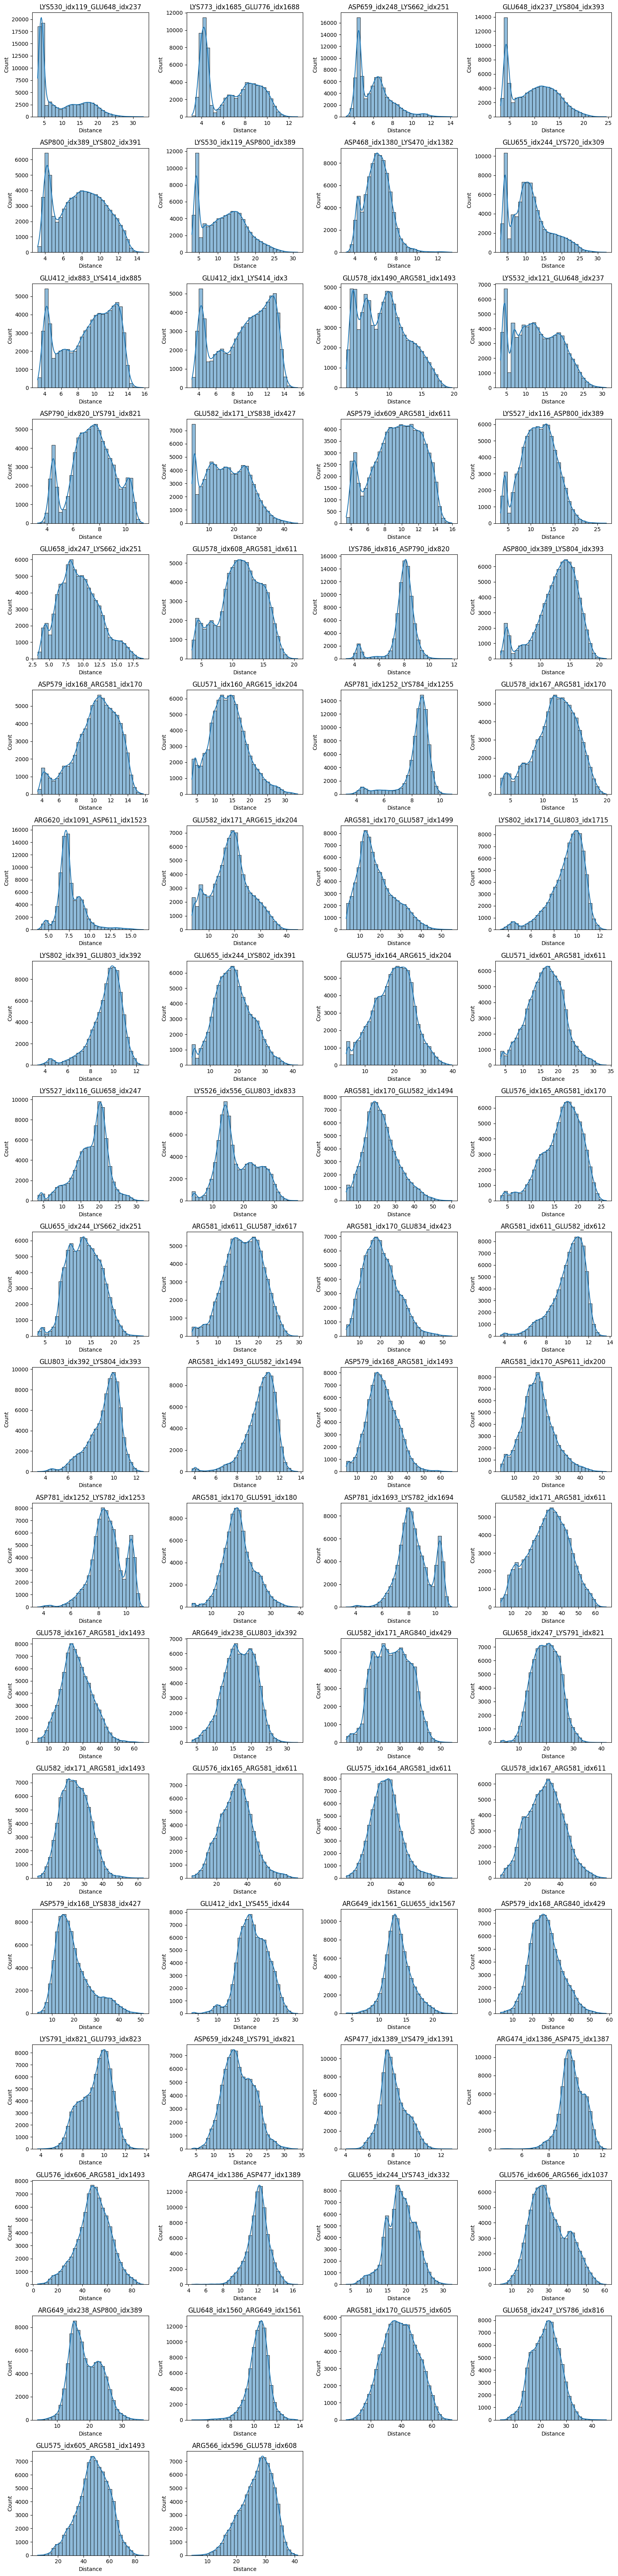

In [174]:
plot_salt_bridge_distributions(dist_df)

In [175]:
summary = dist_df.describe().T

summary = summary[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

print(summary)

                                 count       mean        std       min  \
Salt bridge                                                              
LYS530_idx119_GLU648_idx237    80160.0   9.385296   6.265409  3.114017   
LYS773_idx1685_GLU776_idx1688  80160.0   6.666701   2.314540  3.142203   
ASP659_idx248_LYS662_idx251    80160.0   6.021991   1.741533  3.181069   
GLU648_idx237_LYS804_idx393    80160.0   9.770236   4.471247  3.117060   
ASP800_idx389_LYS802_idx391    80160.0   7.834879   2.609018  3.202646   
...                                ...        ...        ...       ...   
GLU648_idx1560_ARG649_idx1561  80160.0  10.401170   0.908116  4.612073   
ARG581_idx170_GLU575_idx605    80160.0  39.156786  11.298256  4.122872   
GLU658_idx247_LYS786_idx816    80160.0  22.060344   5.275048  4.499493   
GLU575_idx605_ARG581_idx1493   80160.0  47.879019  12.328717  4.149927   
ARG566_idx596_GLU578_idx608    80160.0  26.939640   5.531194  4.697466   

                                     

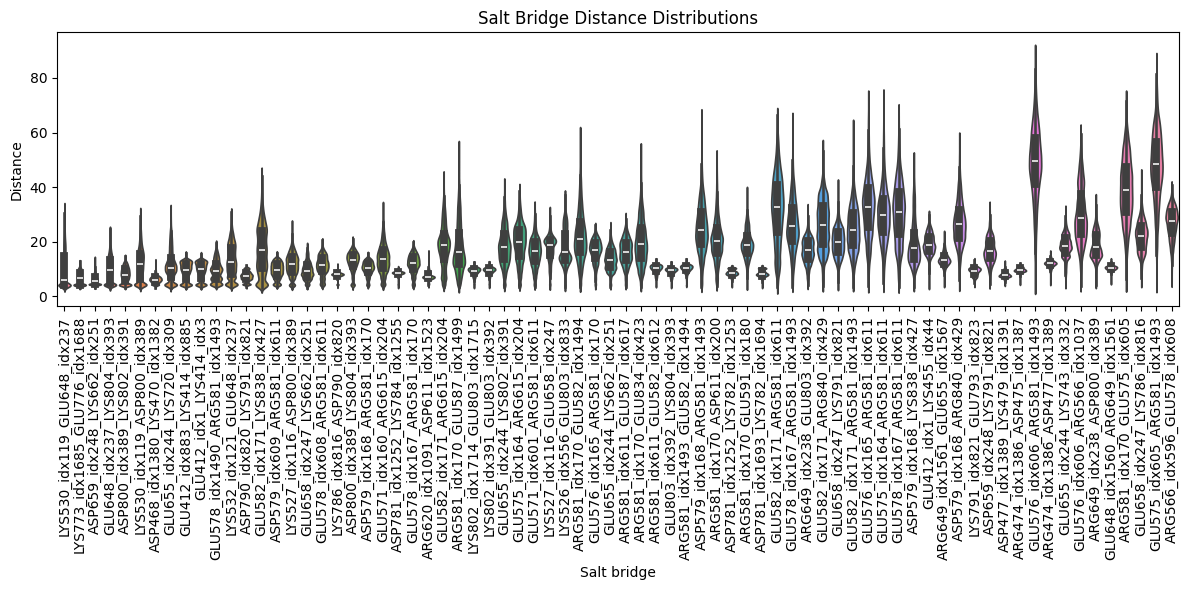

In [176]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=dist_df,
    inner="box"
)

plt.xlabel("Salt bridge")
plt.ylabel("Distance")
plt.title("Salt Bridge Distance Distributions")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

/var/data/python/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:580: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


<Axes: >

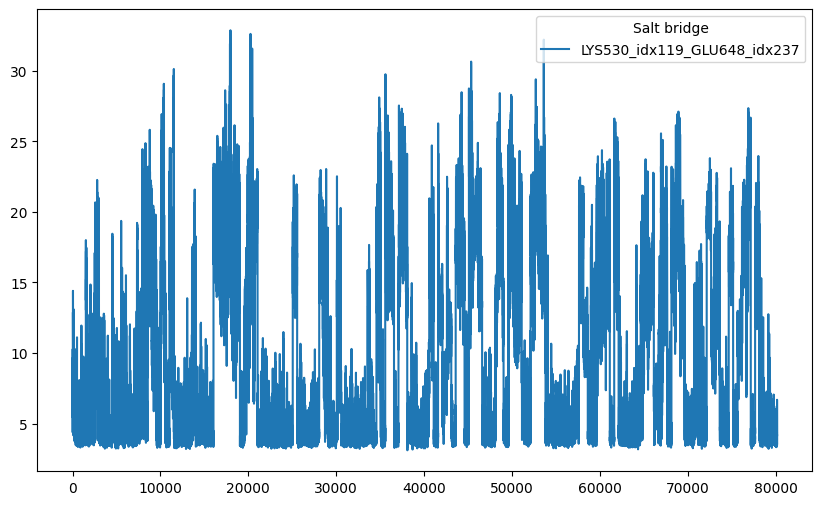

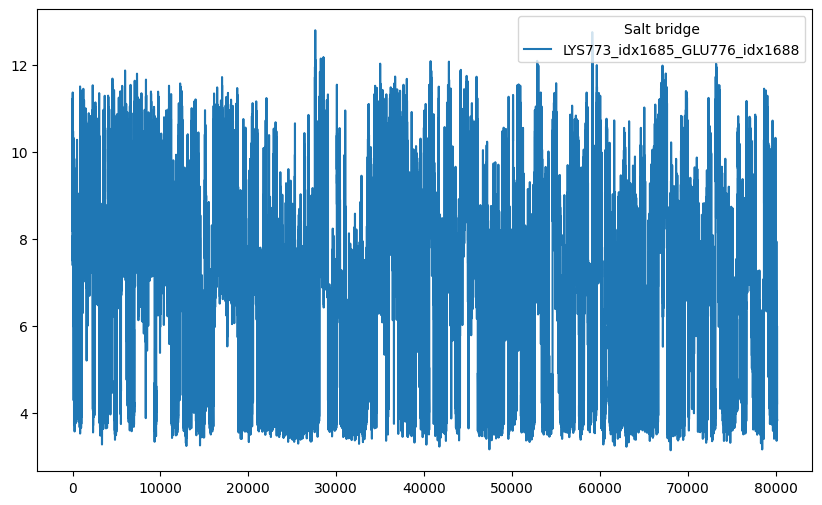

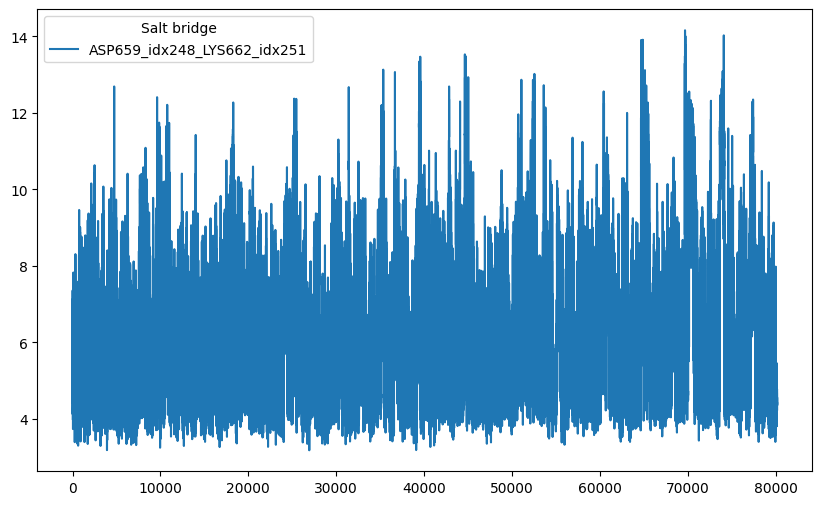

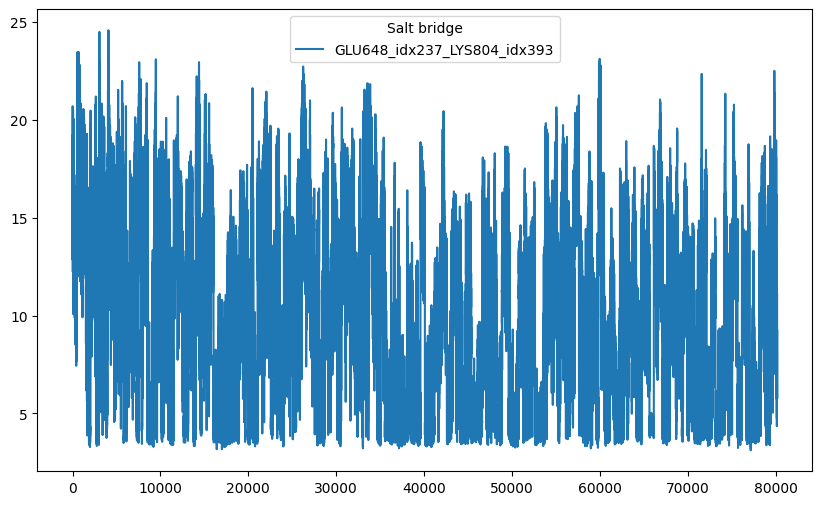

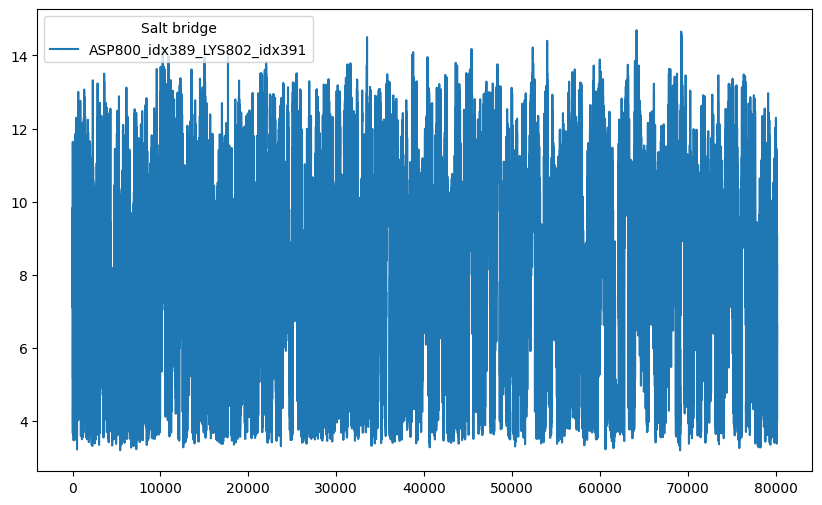

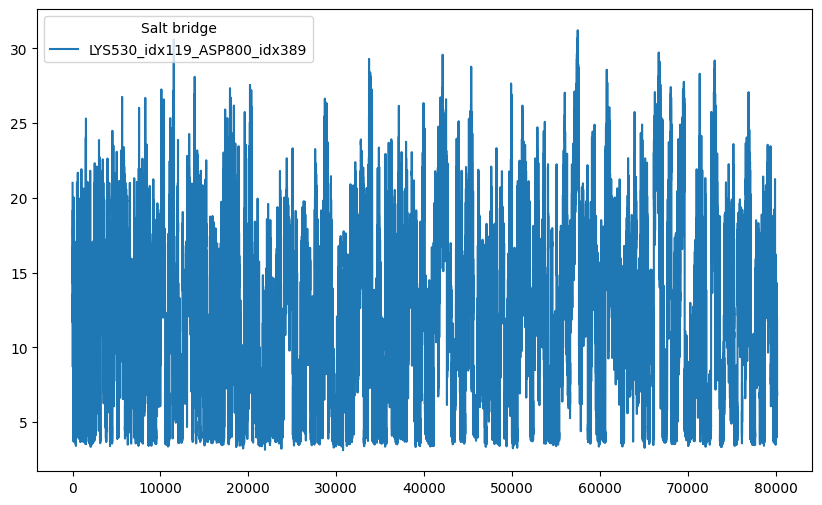

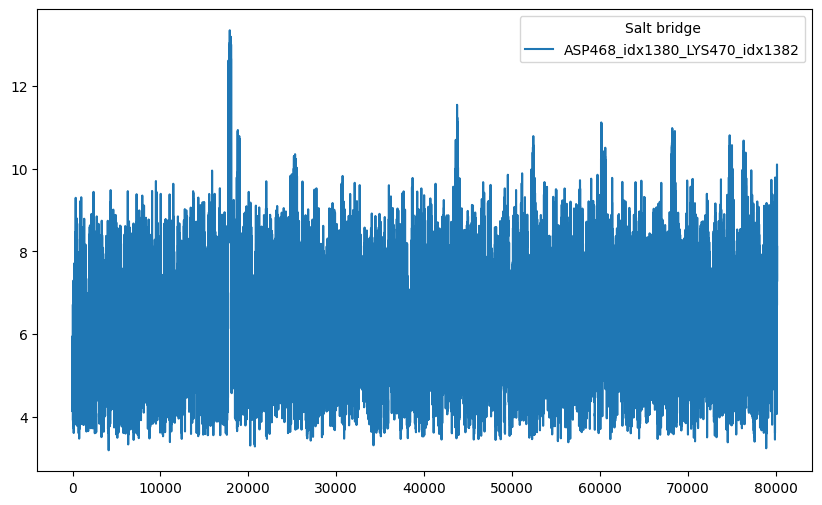

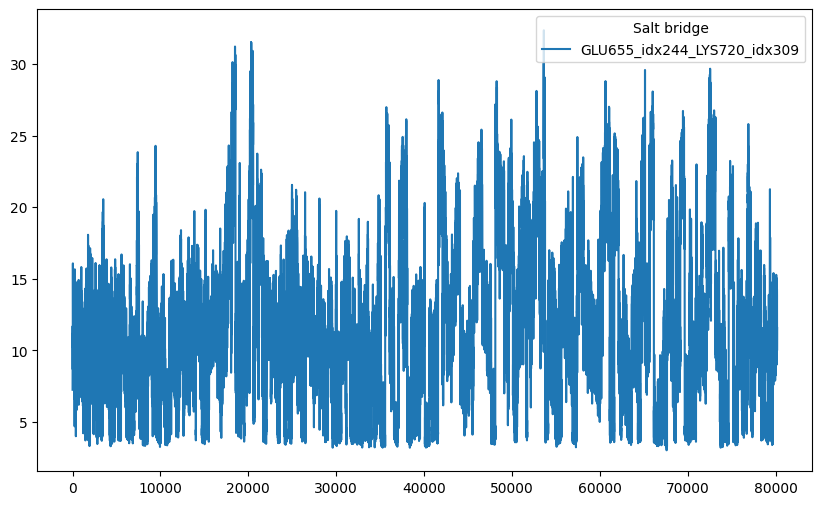

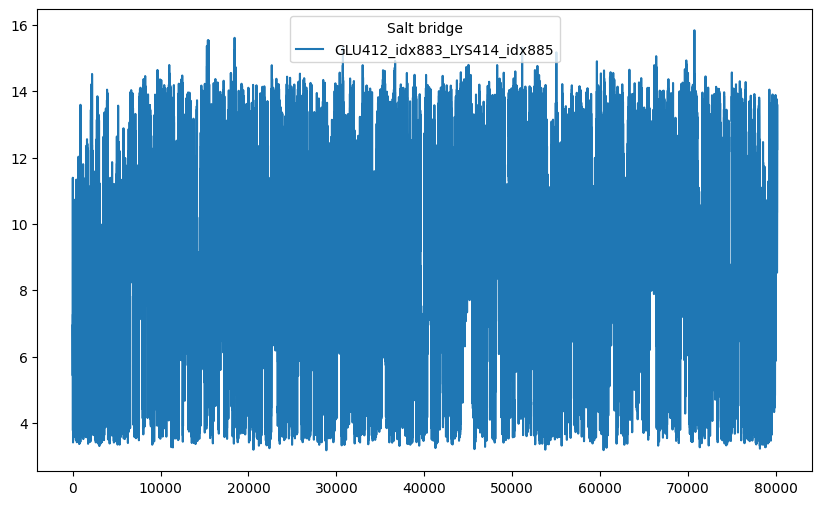

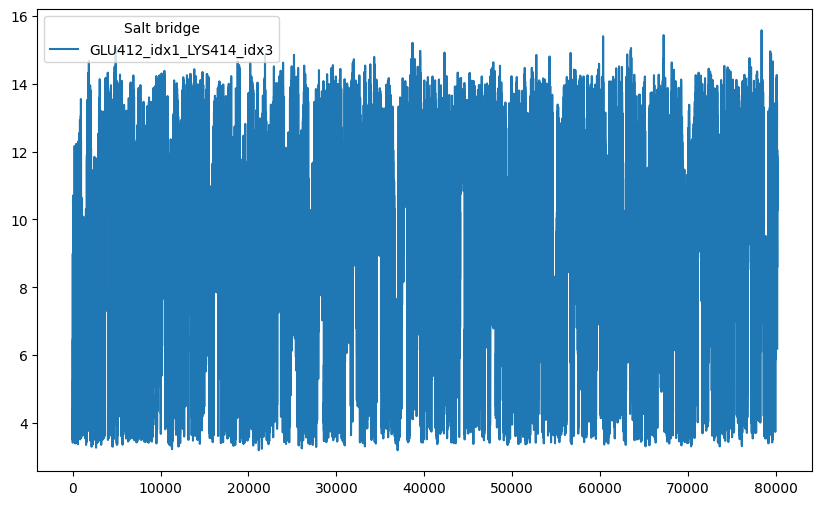

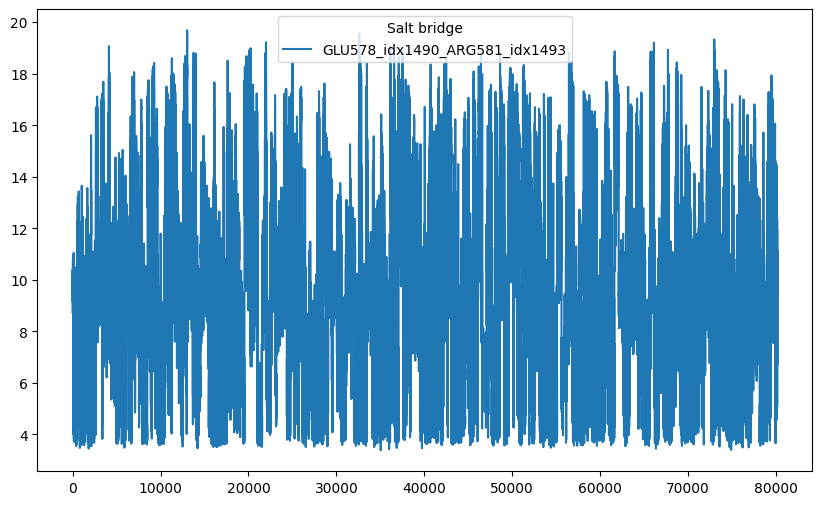

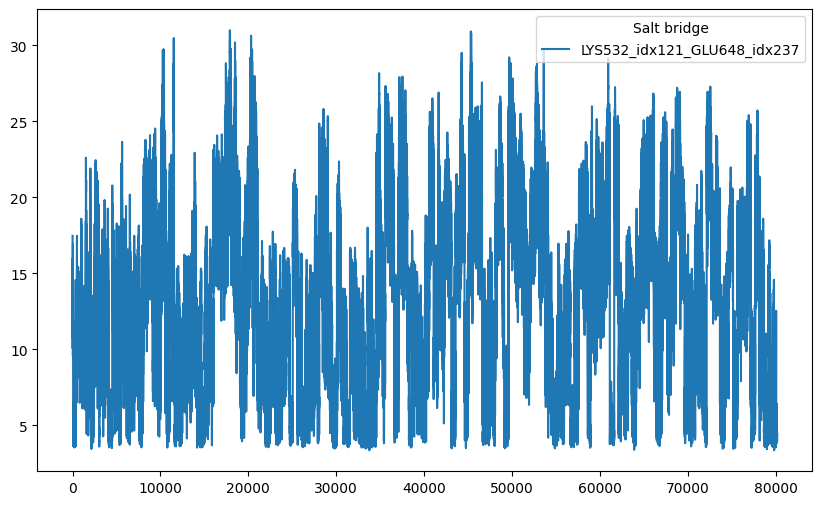

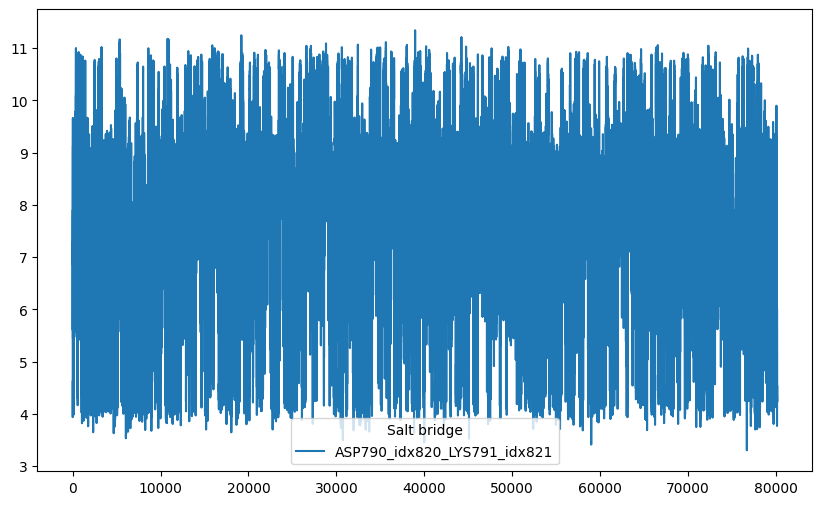

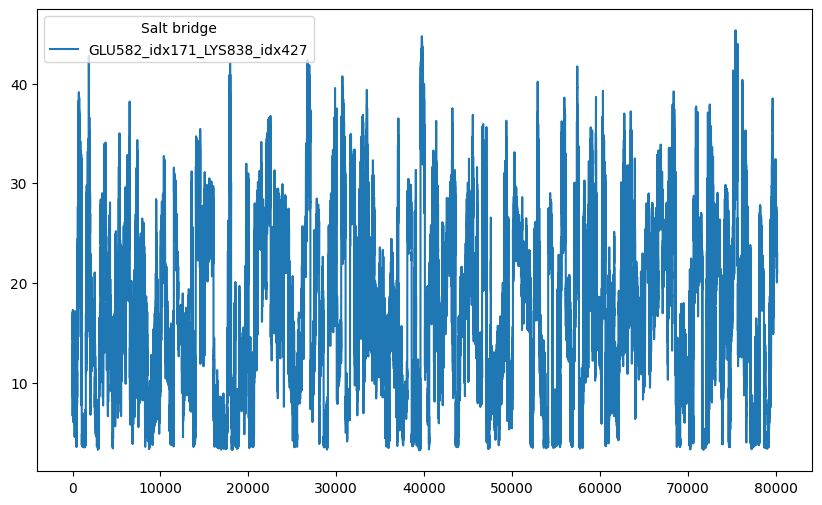

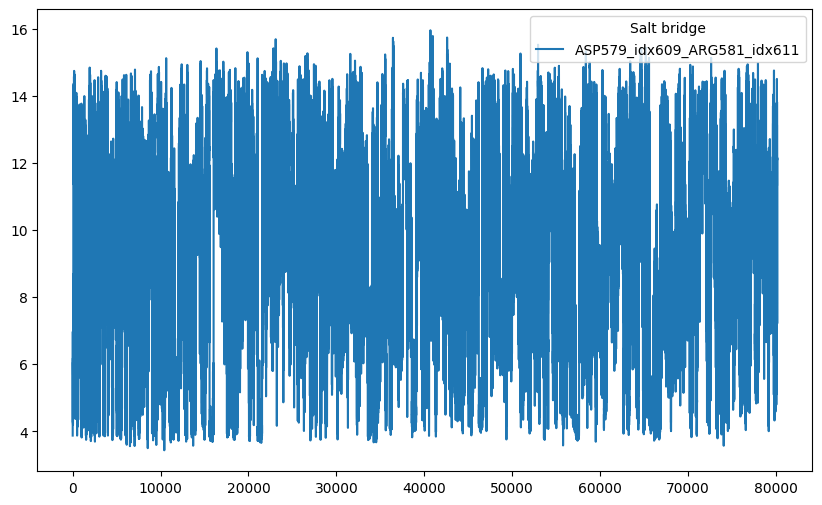

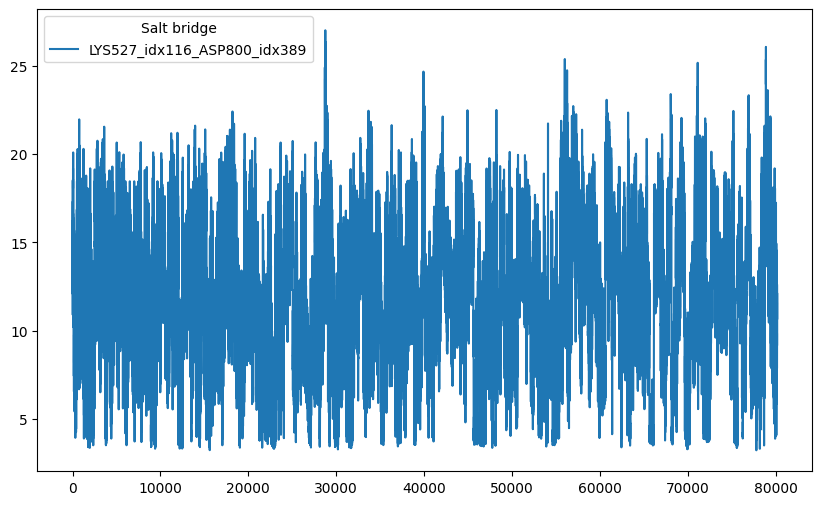

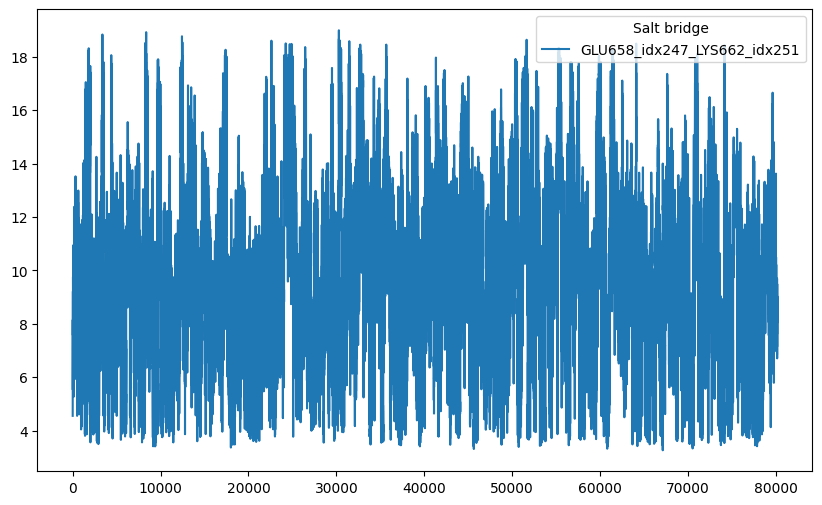

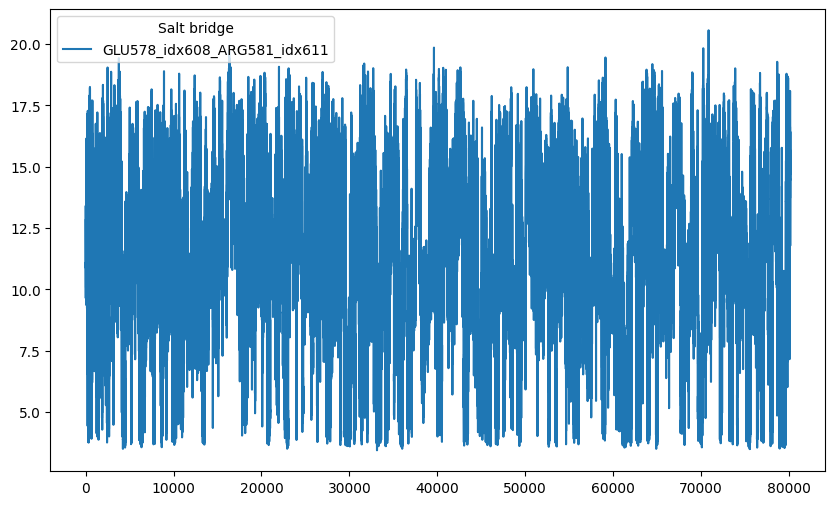

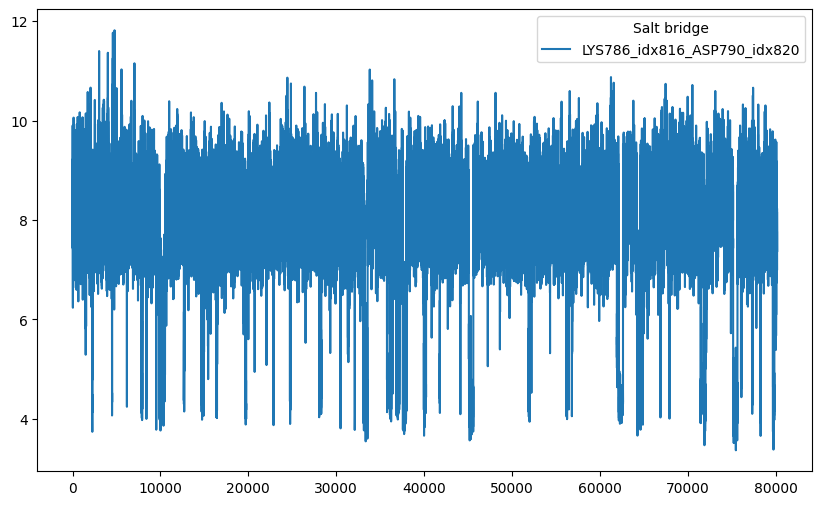

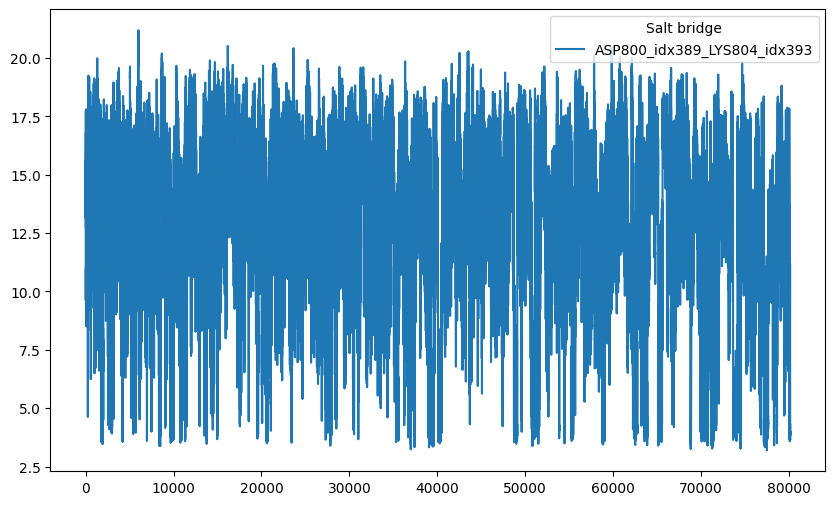

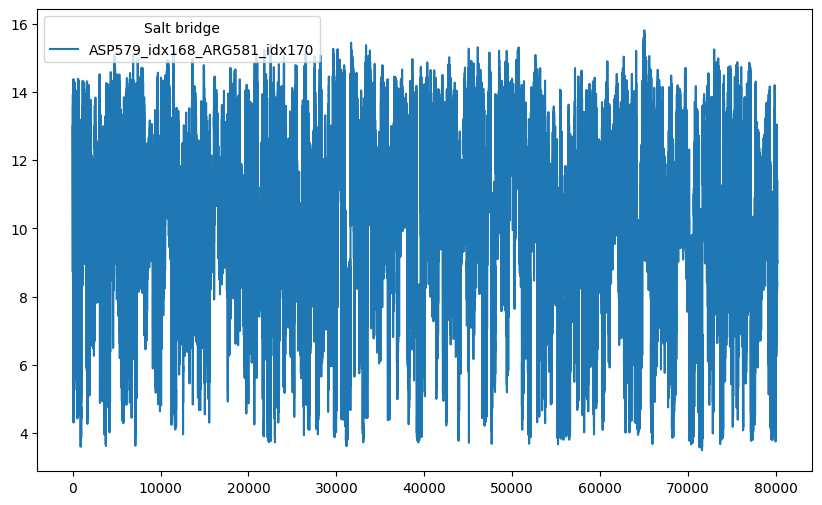

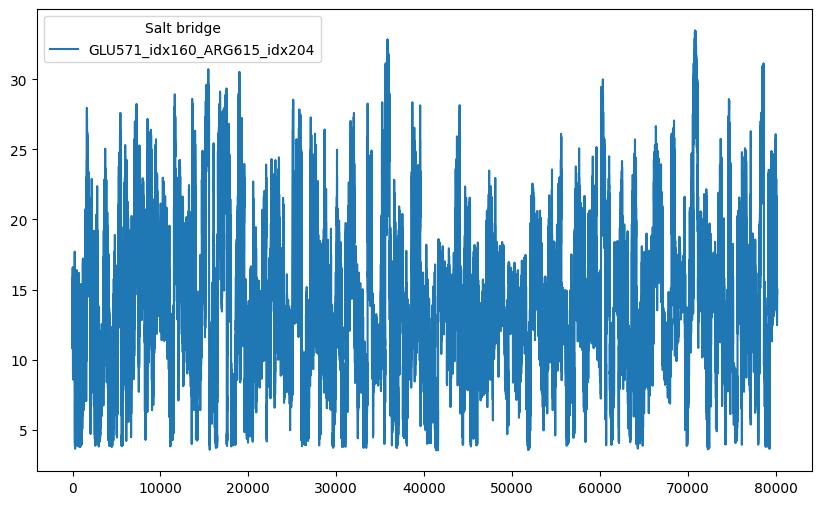

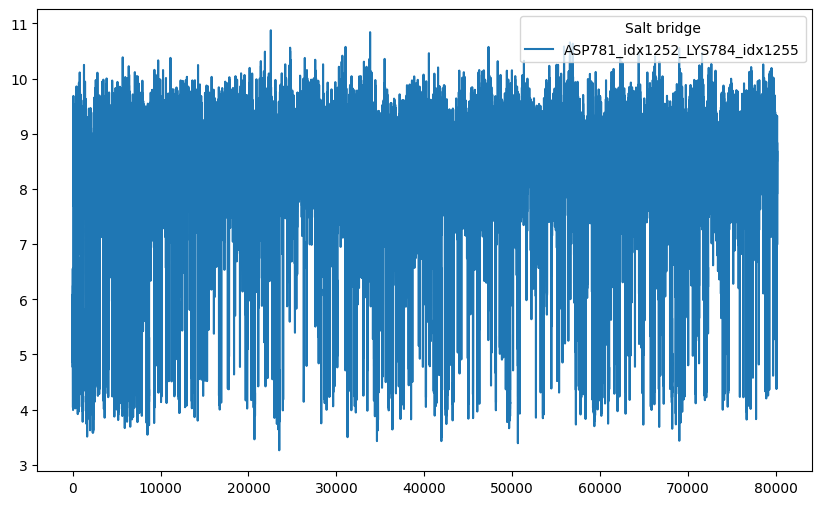

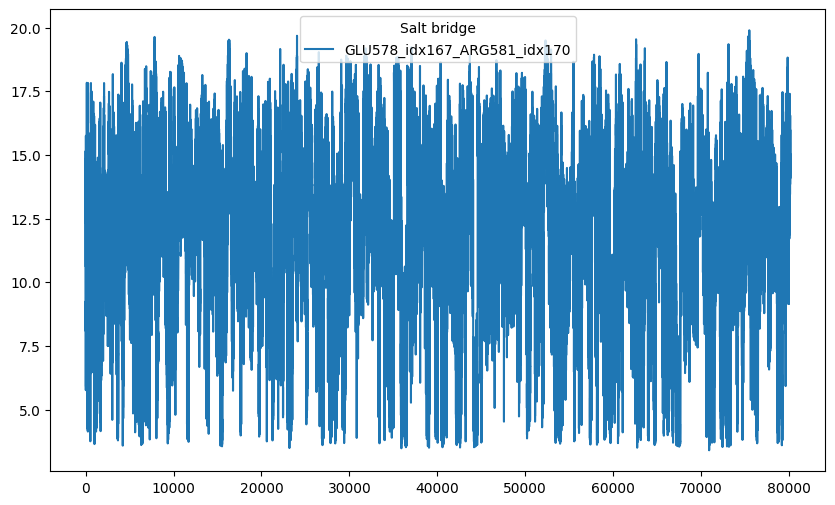

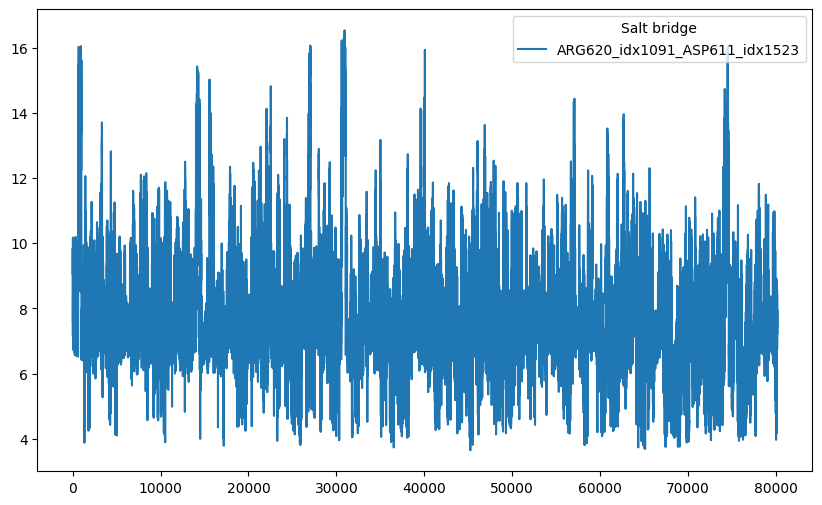

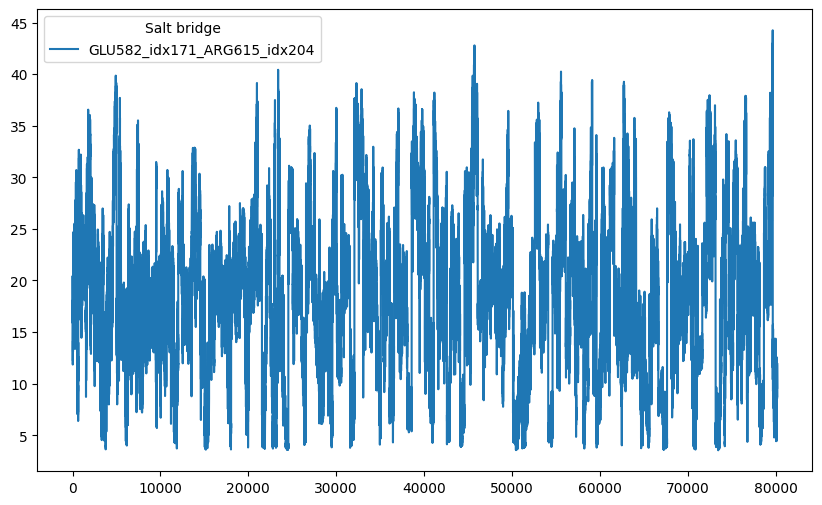

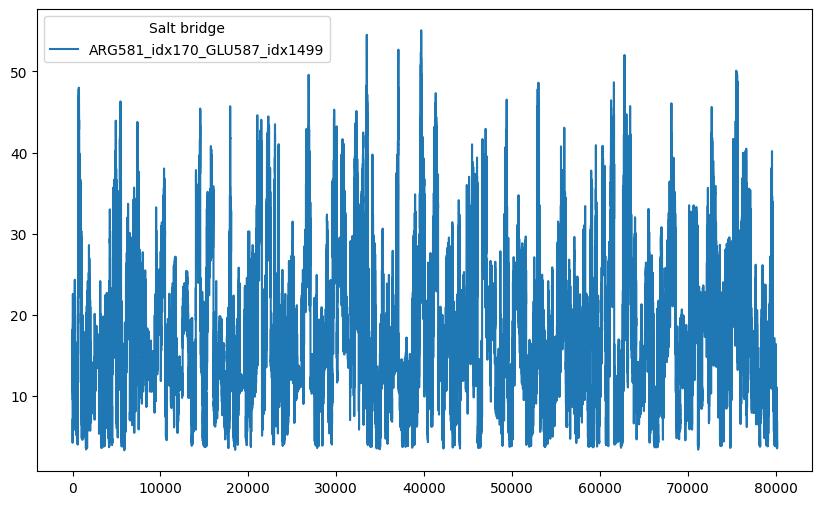

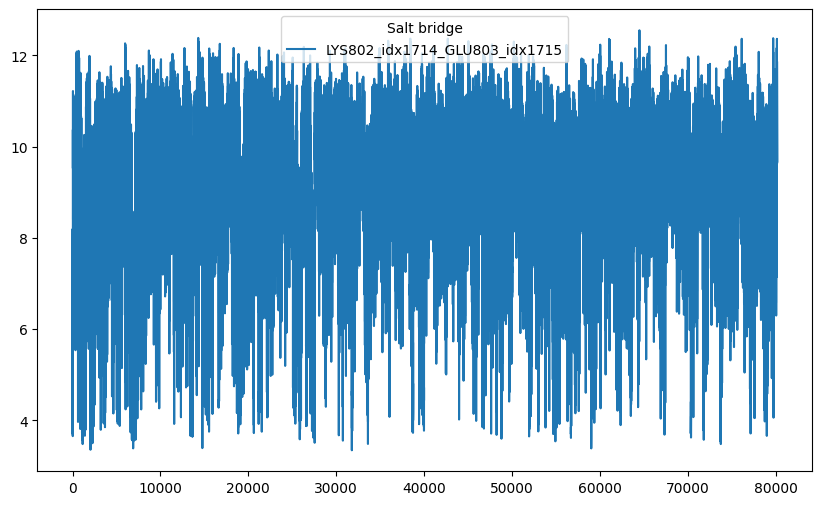

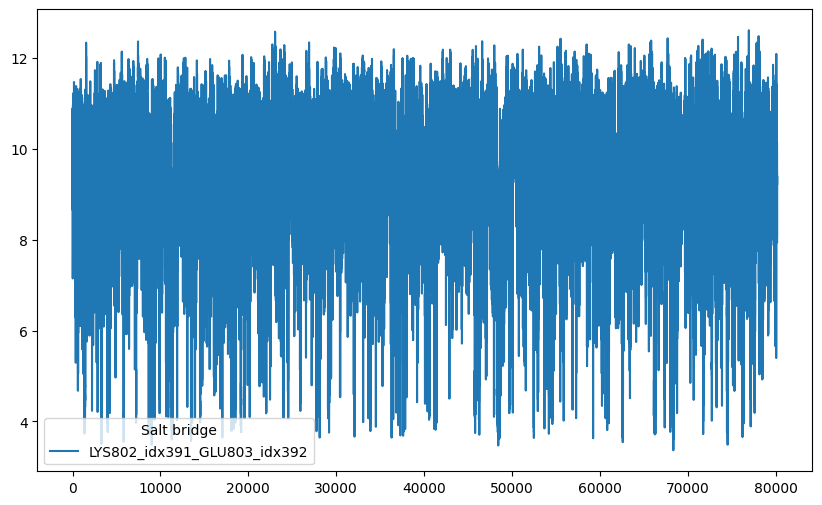

In [177]:
df2 = dist_df
sb_names = sb_names

df2.plot.line(y=[f'{sb_names[0]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[1]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[2]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[3]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[4]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[5]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[6]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[7]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[8]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[9]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[10]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[11]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[12]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[13]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[14]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[15]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[16]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[17]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[18]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[19]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[20]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[21]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[22]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[23]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[24]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[25]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[26]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[27]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[28]}'],  figsize=(10,6))

## PLS ##

In [178]:
# Here add the function data to be used in PLS

Y = function_values#np.load(DATA / "dot_products.npy")
print(Y.shape)

(80160,)


In [179]:
distance_scaled = shap_functions.scale_features(distance_map)
print(distance_scaled.shape)
print(distance_map.shape)

(80160, 74)
(74, 80160)


In [180]:
X_scaled = ba.create_contact_dataframe(contact_map_names, distance_scaled)

Done! Built models up to 10 components.


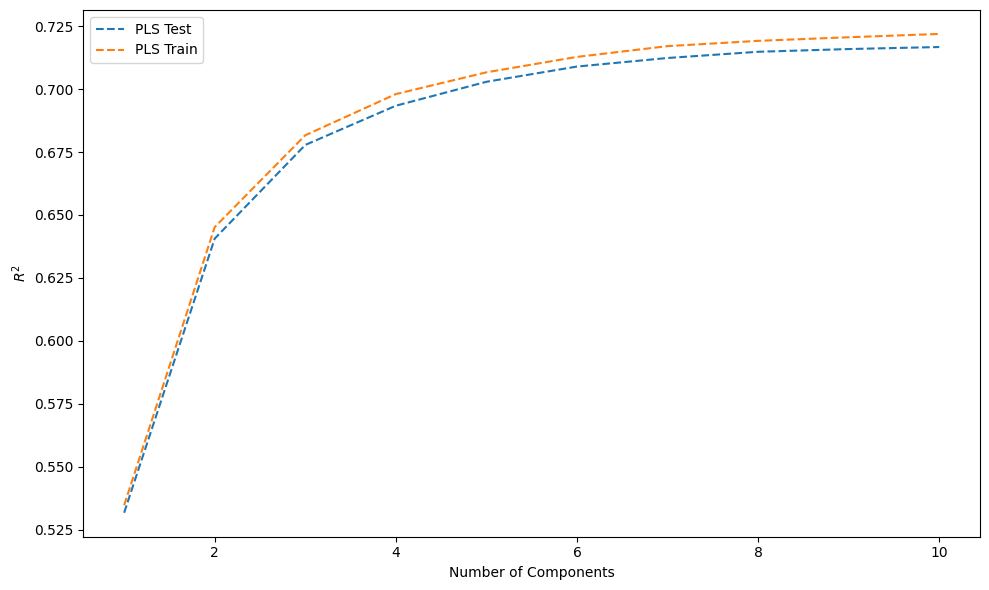

In [181]:
scores = shap_functions.optimize_n_components(X_scaled, Y, maxcomp=10)

In [182]:
print(scores)

(10, 4)


In [183]:
pls = shap_functions.pls_model(X_scaled, Y, 2)

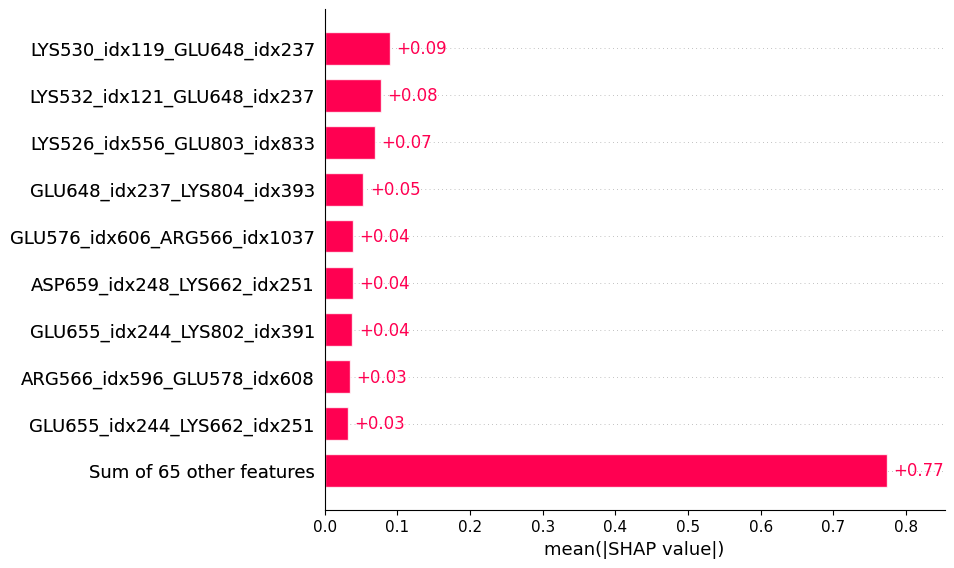

In [184]:
shap_values_pls = shap_functions.compute_shap_values(pls, X_scaled)
shap.plots.bar(shap_values_pls)
feature_names = shap_values_pls.feature_names


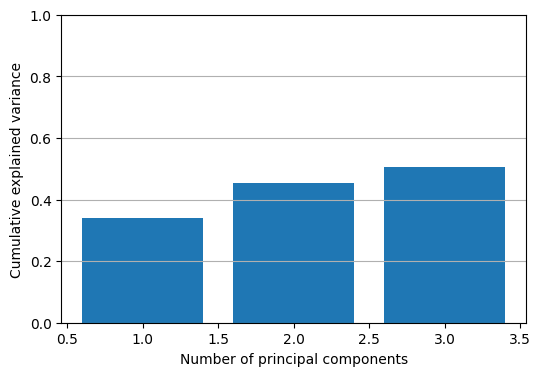

In [185]:
shap_pca,pca = shap_functions.dimensionality_reduction_pca(shap_values_pls, n_comp=3)

In [186]:
loadings = pca.components_.T

loading_df = pd.DataFrame(
    loadings,
    index=shap_values_pls.feature_names,
    columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7"]
)

print(loading_df)

ValueError: Shape of passed values is (74, 3), indices imply (74, 7)

: 

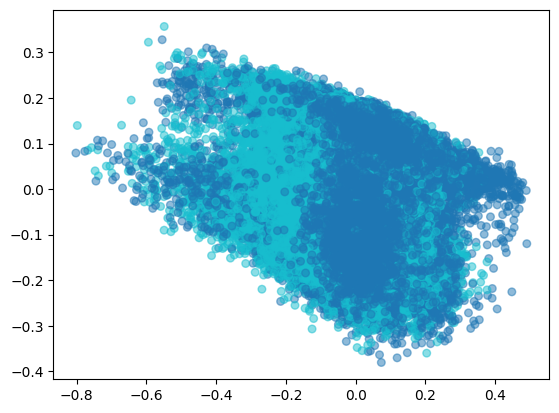

In [ ]:
plt.scatter(
    shap_pca[:, 0],
    shap_pca[:, 1],
    c=cluster_labels,
    cmap="tab10",
    alpha=0.5,
    s=30
)

similar patterns of feature contributions to the PLS function

In [ ]:

def check_clusters(cluster_labels):
    """
    Check which clusters are populated and how many observations
    belong to each cluster.
    """

    unique_clusters, cluster_counts = np.unique(
        cluster_labels,
        return_counts=True
    )

    print("Clusters found:")
    
    for cluster, count in zip(unique_clusters, cluster_counts):
        print(f"Cluster {cluster}: {count} observations")

    print(f"\nNumber of populated clusters: {len(unique_clusters)}")

    return unique_clusters, cluster_counts
    
def cluster_shap_values(
    shap_pca,
    shap_values,
    n_components=4,
    reg_covar=0.001,
):
    if isinstance(shap_values, shap.Explanation):
        feature_names = shap_values.feature_names
        shap_values = shap_values.values
    else:
        shap_values = np.asarray(shap_values)
        feature_names = [
            f"Feature_{i}"
            for i in range(shap_values.shape[1])
        ]

    # Convert PCA values to NumPy array
    shap_pca = np.asarray(shap_pca)

    gmm = BGMM(
        n_components=n_components,
        reg_covar=reg_covar,
        max_iter=1000,
        tol=1e-4,
        random_state=42
    )

    cluster_labels = gmm.fit_predict(shap_pca)
    shap_df = pd.DataFrame(
        shap_values,
        columns=feature_names
    )

    shap_df["Cluster"] = cluster_labels


    cluster_means = shap_df.groupby("Cluster").mean()

    print("Mean SHAP Values per Cluster:")
    print(cluster_means)

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        shap_pca[:, 0],
        shap_pca[:, 1],
        c=cluster_labels,
        cmap="tab10",
        alpha=0.6
    )

    plt.colorbar(scatter, label="Cluster")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("BGMM Clustering of SHAP Values")
    plt.show()

    return gmm, cluster_labels, cluster_means

Mean SHAP Values per Cluster:
         ASP477_LYS479  ARG474_ASP475  ARG474_ASP477  GLU578_ARG581  \
Cluster                                                               
0            -0.000436       0.011507      -0.002705       0.001507   
1            -0.001499       0.005501      -0.006849       0.003547   

         ARG581_GLU582  ARG649_GLU655  GLU648_ARG649  LYS802_GLU803  \
Cluster                                                               
0             0.000014       0.004726      -0.006006      -0.005737   
1             0.000027       0.001996      -0.014430       0.003135   

         ASP781_LYS782  LYS773_GLU776  
Cluster                                
0            -0.000242       0.130090  
1            -0.000144      -0.085601  


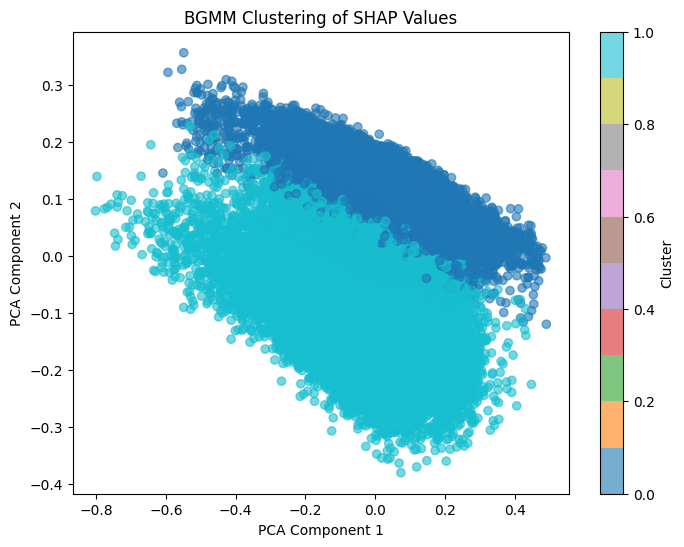

Clusters found:
Cluster 0: 34905 observations
Cluster 1: 45255 observations

Number of populated clusters: 2


In [ ]:
gmm, cluster_labels, cluster_means = cluster_shap_values(
    shap_pca,
    shap_values_pls,
    n_components=2,
    reg_covar=0.001
)

unique_clusters, cluster_counts = check_clusters(
    cluster_labels
)

In [ ]:
# Check cluster sizes
unique_clusters, counts = np.unique(
    cluster_labels,
    return_counts=True
)

print("\nCluster distribution:")
for cluster, count in zip(unique_clusters, counts):
    print(f"Cluster {cluster}: {count}")

print("\nBGMM weights:")
print(gmm.weights_)

# Assignment probabilities
probs = gmm.predict_proba(shap_pca)

max_probs = probs.max(axis=1)

print("\nMean maximum assignment probability:",
      max_probs.mean())

print("Minimum maximum assignment probability:",
      max_probs.min())


Cluster distribution:
Cluster 0: 34905
Cluster 1: 45255

BGMM weights:
[0.43514002 0.56485998]

Mean maximum assignment probability: 0.9716351261395152
Minimum maximum assignment probability: 0.500009725676459


In [ ]:
# Check cluster sizes
unique_clusters, counts = np.unique(
    cluster_labels,
    return_counts=True
)

print("\nCluster distribution:")
for cluster, count in zip(unique_clusters, counts):
    print(f"Cluster {cluster}: {count}")

print("\nBGMM weights:")
print(gmm.weights_)

# Assignment probabilities
probs = gmm.predict_proba(shap_pca)

max_probs = probs.max(axis=1)

print("\nMean maximum assignment probability:",
      max_probs.mean())

print("Minimum maximum assignment probability:",
      max_probs.min())


Cluster distribution:
Cluster 0: 48486
Cluster 1: 31674

BGMM weights:
[0.59839519 0.40160481]

Mean maximum assignment probability: 0.981830928999199
Minimum maximum assignment probability: 0.5002486924287477


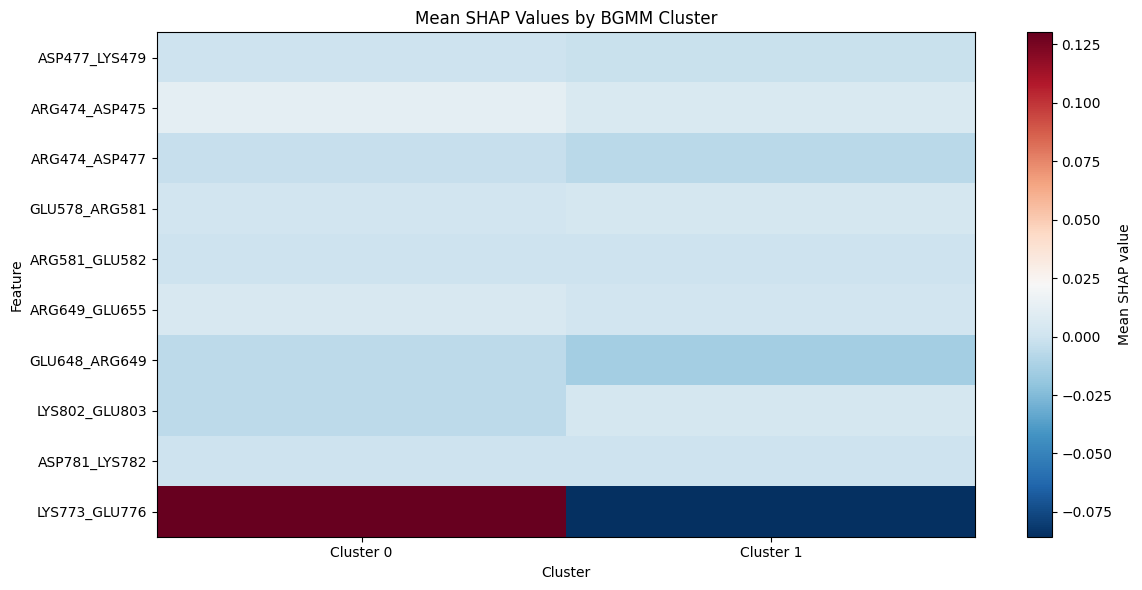

In [ ]:
plt.figure(figsize=(12, 6))

plt.imshow(
    cluster_means.T,
    aspect="auto",
    cmap="RdBu_r"
)

plt.colorbar(label="Mean SHAP value")

plt.xticks(
    range(len(cluster_means)),
    [f"Cluster {i}" for i in cluster_means.index]
)

plt.yticks(
    range(len(cluster_means.columns)),
    cluster_means.columns
)

plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.title("Mean SHAP Values by BGMM Cluster")

plt.tight_layout()
plt.show()